# Notebook 00 — Exploración y Análisis Descriptivo (EDA)
**Proyecto Final ML · Comillas ICAI · 2025/2026**

Dependencias: `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`

## 0. Imports y configuración

In [1]:
import sys, os
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils import load_data, set_plot_style, plot_class_distribution, RANDOM_STATE

os.makedirs("../outputs", exist_ok=True)
set_plot_style()

## 1. Carga del dataset

In [2]:
df = load_data("../rendimiento_estudiantes.csv")
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head(3)

Dimensiones: 4424 filas × 37 columnas


,estado_civil,modo_solicitud,orden_solicitud,curso,asistencia_diurna_vespertina,cualificacion_previa,nota_cualificacion_previa,nacionalidad,cualificacion_madre,cualificacion_padre,...,asignaturas_2sem_convalidadas,asignaturas_2sem_matriculadas,asignaturas_2sem_evaluadas,asignaturas_2sem_aprobadas,nota_media_2sem,asignaturas_2sem_sin_evaluacion,tasa_desempleo,tasa_inflacion,pib,objetivo
0,soltero/a,2a_fase_contingente_general,5,animacion_y_diseno_multimedia,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_3er_ciclo_o_equivalente,otro_11o_ano,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,abandono
1,soltero/a,estudiante_internacional_licenciatura,1,turismo,diurna,educacion_secundaria,160.0,portuguesa,educacion_secundaria_12o_ano_o_equivalente,educacion_superior_grado,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,graduado
2,soltero/a,1a_fase_contingente_general,5,diseno_de_comunicacion,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_1er_ciclo_o_equivalente,educacion_basica_1er_ciclo_o_equivalente,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,abandono


## 2. Tipos de variables y valores perdidos

In [3]:
info = pd.DataFrame({
    "dtype":     df.dtypes,
    "n_unicos":  df.nunique(),
    "n_nulos":   df.isnull().sum(),
    "pct_nulos": (df.isnull().mean() * 100).round(2),
})
print(info.to_string())

                                     dtype  n_unicos  n_nulos  pct_nulos
estado_civil                           str         6        0        0.0
modo_solicitud                         str        18        0        0.0
orden_solicitud                      int64         8        0        0.0
curso                                  str        17        0        0.0
asistencia_diurna_vespertina           str         2        0        0.0
cualificacion_previa                   str        17        0        0.0
nota_cualificacion_previa          float64       101        0        0.0
nacionalidad                           str        21        0        0.0
cualificacion_madre                    str        29        0        0.0
cualificacion_padre                    str        34        0        0.0
ocupacion_madre                        str        32        0        0.0
ocupacion_padre                        str        46        0        0.0
nota_admision                      float64       62

In [4]:
nulos = df.isnull().sum()
if nulos.any():
    print("Columnas con nulos:")
    print(nulos[nulos > 0])
else:
    print("Sin valores nulos — dataset completo.")

Sin valores nulos — dataset completo.


## 3. Distribución de la variable objetivo

/Users/claudialbombin/Desktop/2025 - 2026/Practicas/Machine/Proyecto final/notebooks/../src/utils.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="Set2")


         graduado:  2209  (49.9%)
         abandono:  1421  (32.1%)
      matriculado:   794  (17.9%)


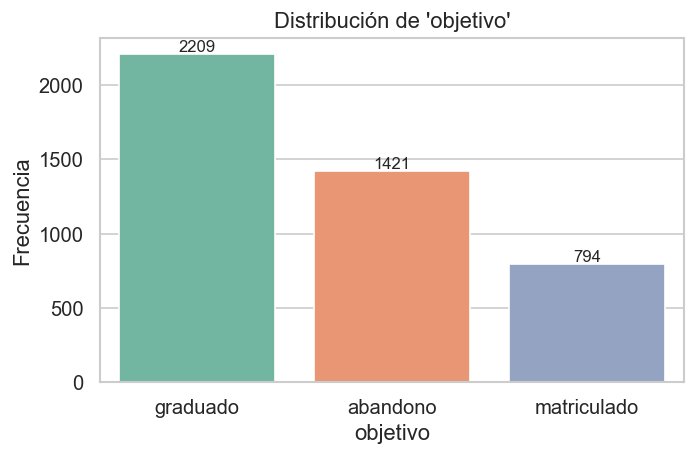

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
plot_class_distribution(df, col="objetivo", ax=ax)
counts = df["objetivo"].value_counts()
total  = len(df)
for cls, cnt in counts.items():
    print(f"  {cls:>15}: {cnt:>5}  ({cnt/total*100:.1f}%)")
plt.tight_layout()
plt.savefig("../outputs/00_distribucion_objetivo.png", bbox_inches="tight")
plt.show()

> **Desbalanceo:** Graduado ≈ 50 %, Abandono ≈ 32 %, Matriculado ≈ 18 %.  
> Se usará `class_weight='balanced'` en los modelos de clasificación.

## 4. Estadísticos descriptivos — Variables numéricas

In [6]:
num_cols = df.select_dtypes(include="number").columns.tolist()
desc = df[num_cols].describe().T
desc["cv"] = (desc["std"] / desc["mean"].replace(0, np.nan)).round(3)
print(desc.round(3).to_string())

                                  count     mean     std    min     25%      50%      75%      max        cv
orden_solicitud                  4424.0    1.728   1.314   0.00    1.00    1.000    2.000    9.000     0.760
nota_cualificacion_previa        4424.0  132.613  13.188  95.00  125.00  133.100  140.000  190.000     0.099
nota_admision                    4424.0  126.978  14.482  95.00  117.90  126.100  134.800  190.000     0.114
edad_al_matricularse             4424.0   23.265   7.588  17.00   19.00   20.000   25.000   70.000     0.326
asignaturas_1sem_convalidadas    4424.0    0.710   2.361   0.00    0.00    0.000    0.000   20.000     3.325
asignaturas_1sem_matriculadas    4424.0    6.271   2.480   0.00    5.00    6.000    7.000   26.000     0.396
asignaturas_1sem_evaluadas       4424.0    8.299   4.179   0.00    6.00    8.000   10.000   45.000     0.504
asignaturas_1sem_aprobadas       4424.0    4.707   3.094   0.00    3.00    5.000    6.000   26.000     0.657
nota_media_1sem    

## 5. Distribuciones de variables numéricas

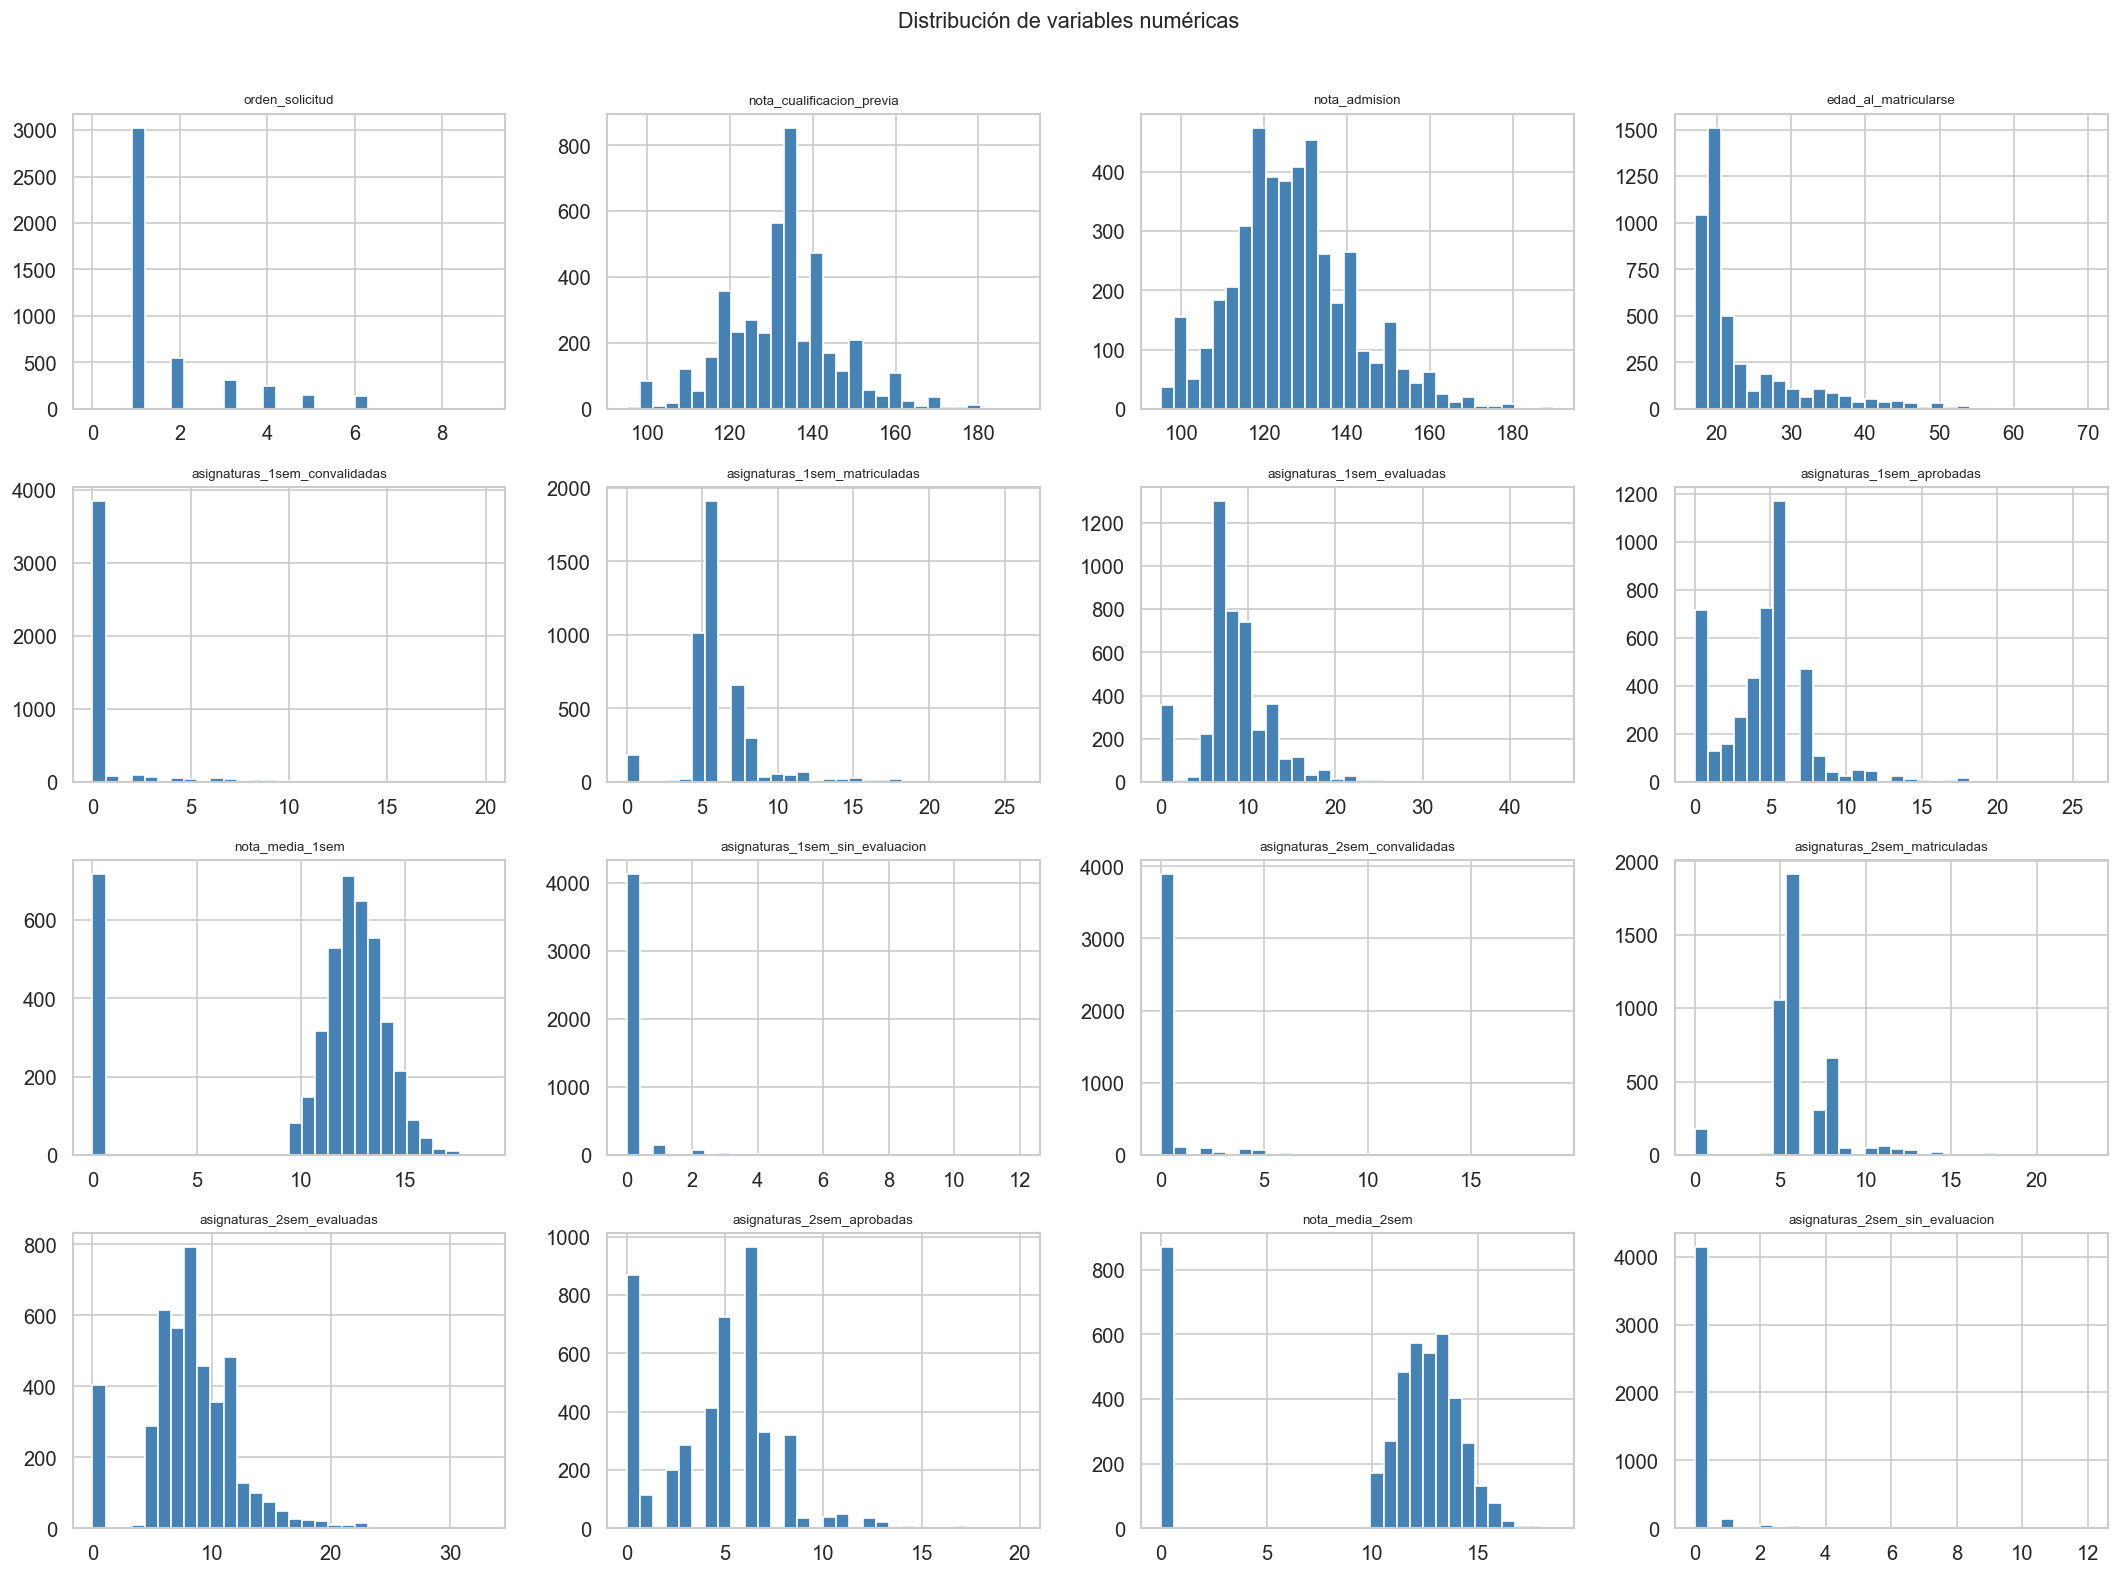

In [7]:
fig, axes = plt.subplots(4, 4, figsize=(18, 13))
axes = axes.flatten()
for i, col in enumerate(num_cols[:16]):
    axes[i].hist(df[col].dropna(), bins=30, color="steelblue", edgecolor="white")
    axes[i].set_title(col, fontsize=8)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Distribución de variables numéricas", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../outputs/00_histogramas_numericas.png", bbox_inches="tight")
plt.show()

## 6. Variables numéricas por clase objetivo (boxplots)

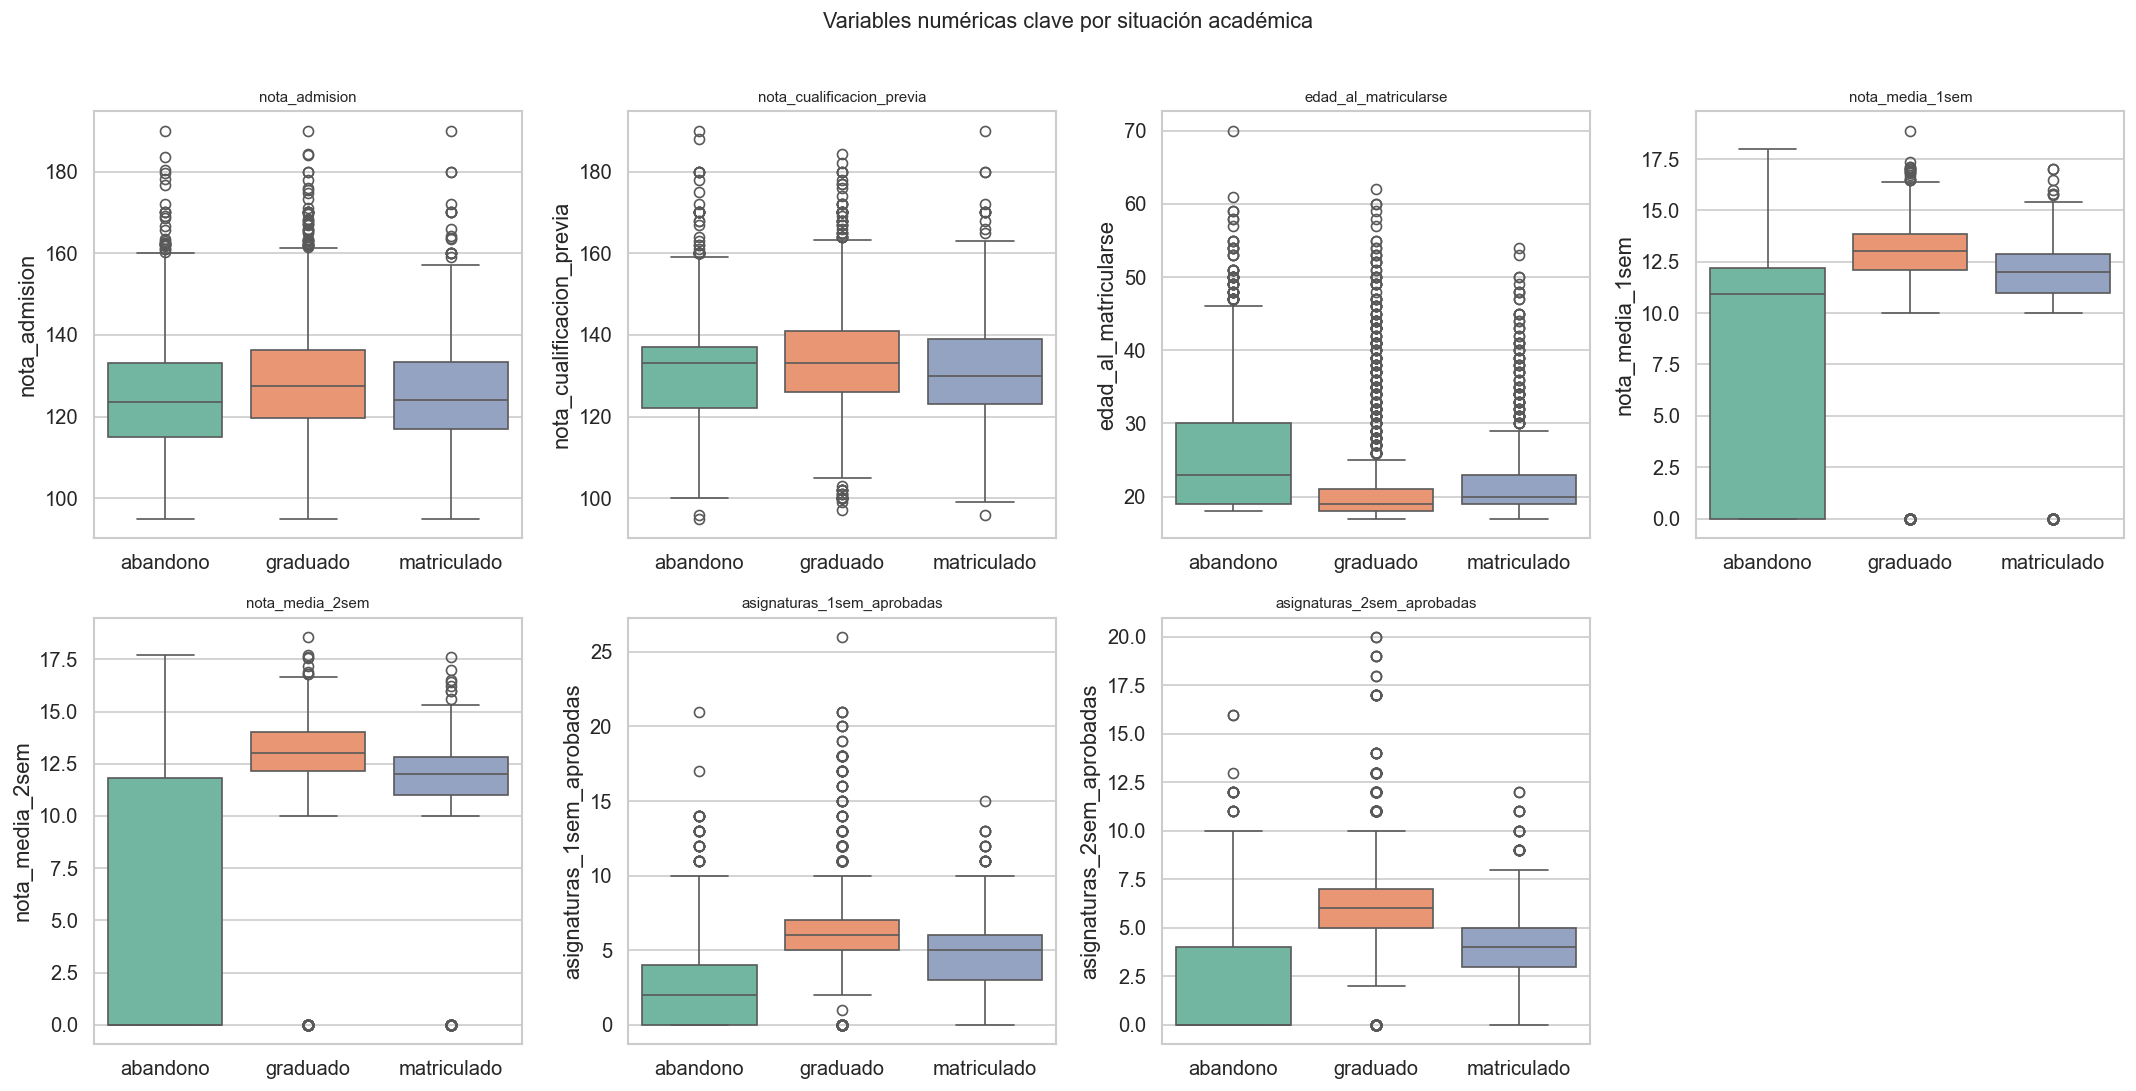

In [8]:
vars_box = [
    "nota_admision", "nota_cualificacion_previa", "edad_al_matricularse",
    "nota_media_1sem", "nota_media_2sem",
    "asignaturas_1sem_aprobadas", "asignaturas_2sem_aprobadas",
]
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(vars_box):
    sns.boxplot(data=df, x="objetivo", y=col,
                hue="objetivo", legend=False,
                palette="Set2", ax=axes[i])
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Variables numéricas clave por situación académica", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../outputs/00_boxplots_objetivo.png", bbox_inches="tight")
plt.show()

## 7. Variables categóricas vs. objetivo

/var/folders/zx/57z_g0c14095702lbtyqdbx00000gn/T/ipykernel_62921/1949956606.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols  = df.select_dtypes(include="object").columns.drop("objetivo").tolist()


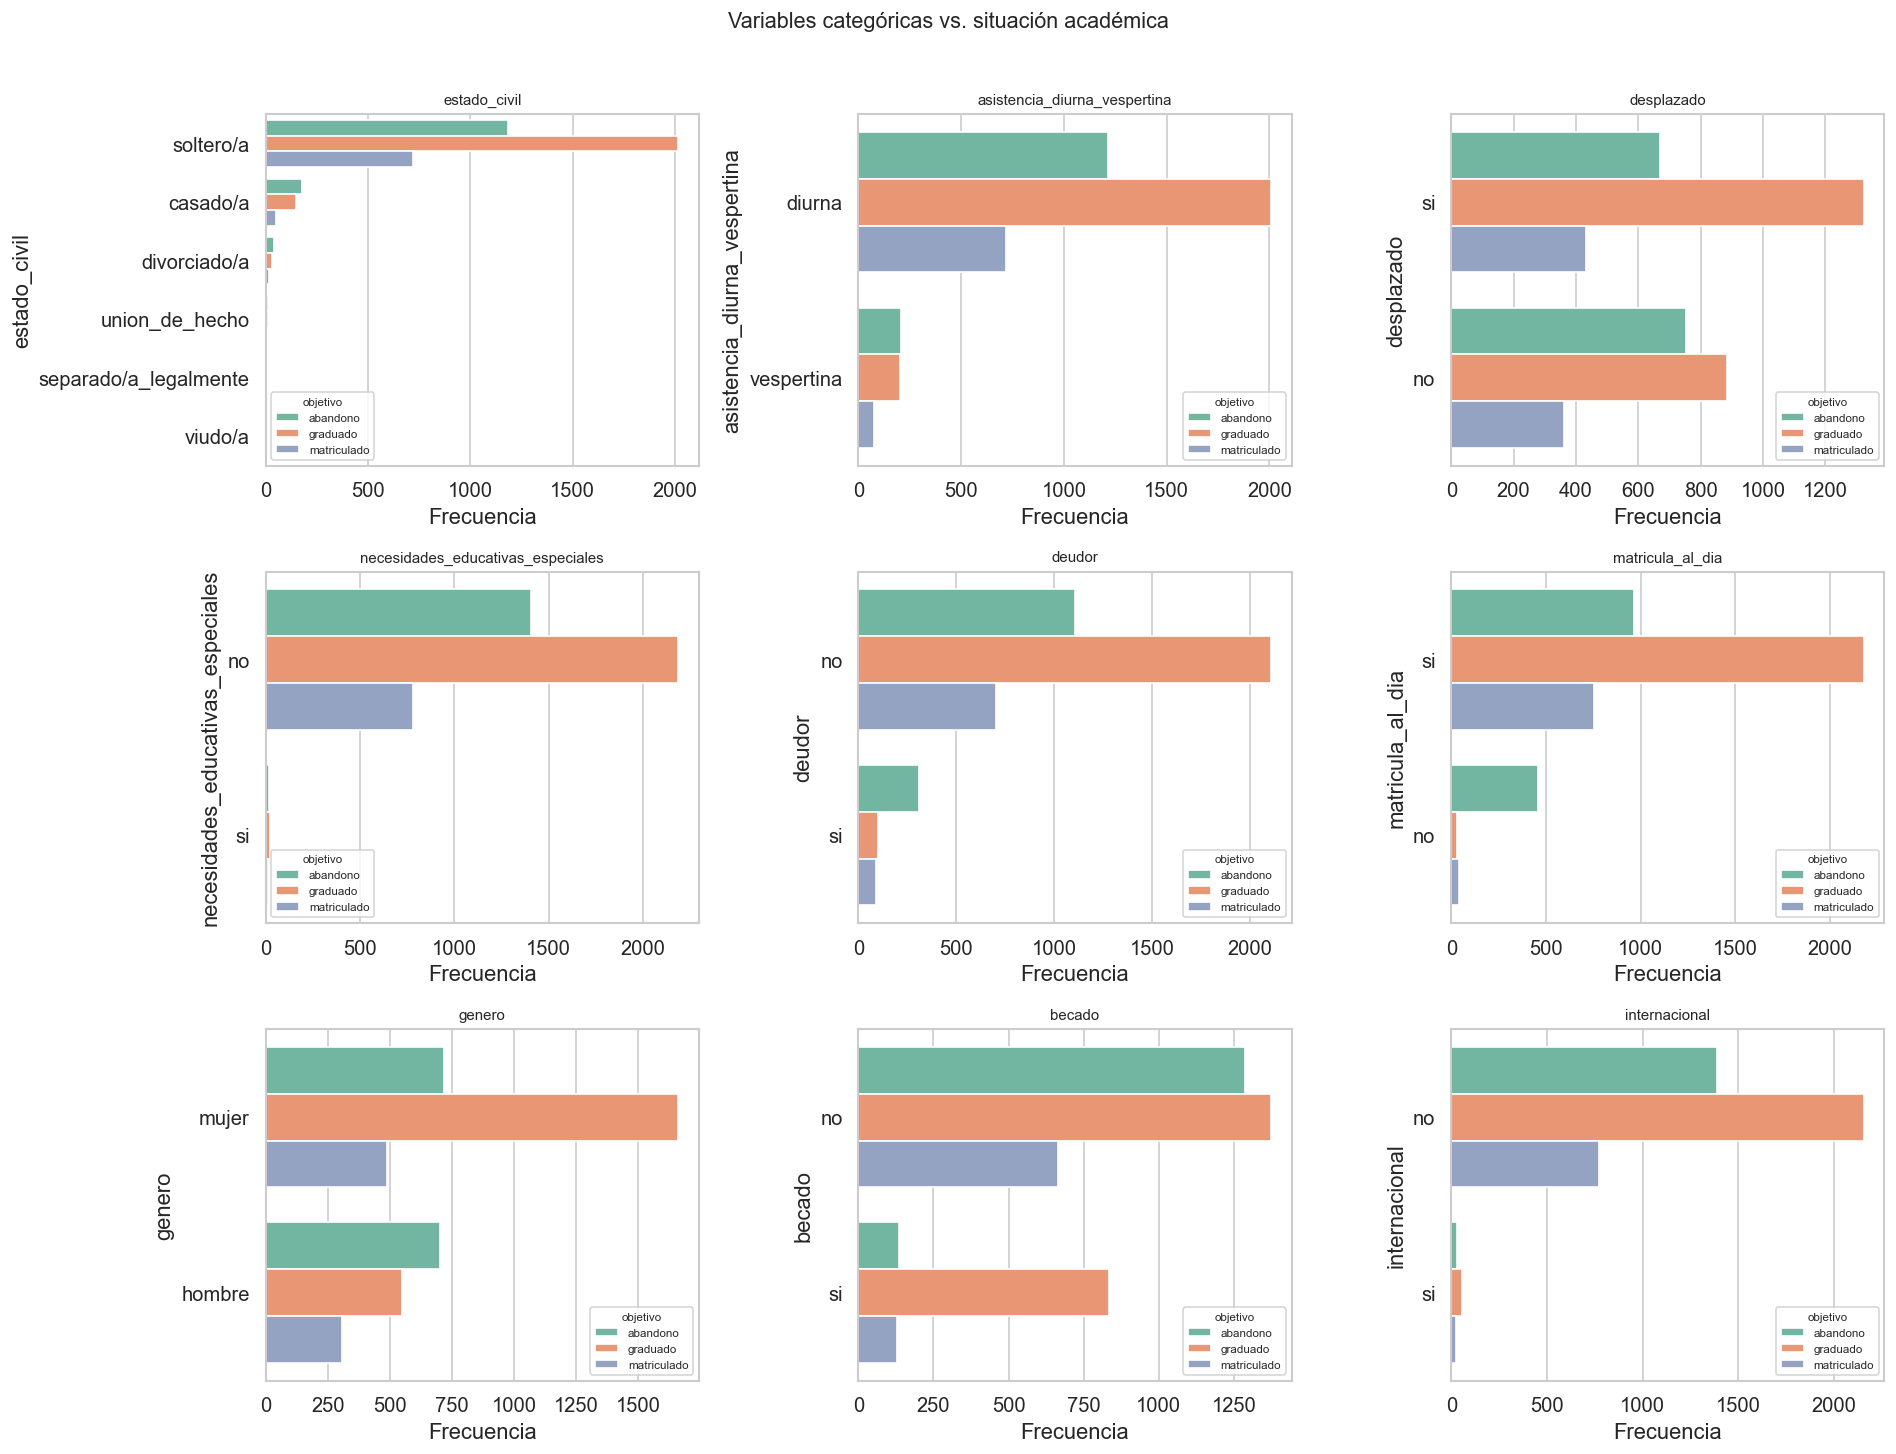

In [9]:
cat_cols  = df.select_dtypes(include="object").columns.drop("objetivo").tolist()
low_card  = [c for c in cat_cols if df[c].nunique() <= 8]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(low_card[:9]):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, hue="objetivo",
                  order=order, palette="Set2", ax=axes[i])
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("Frecuencia")
    axes[i].legend(fontsize=7, title="objetivo", title_fontsize=7)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Variables categóricas vs. situación académica", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../outputs/00_categoricas_objetivo.png", bbox_inches="tight")
plt.show()

## 8. Matriz de correlación

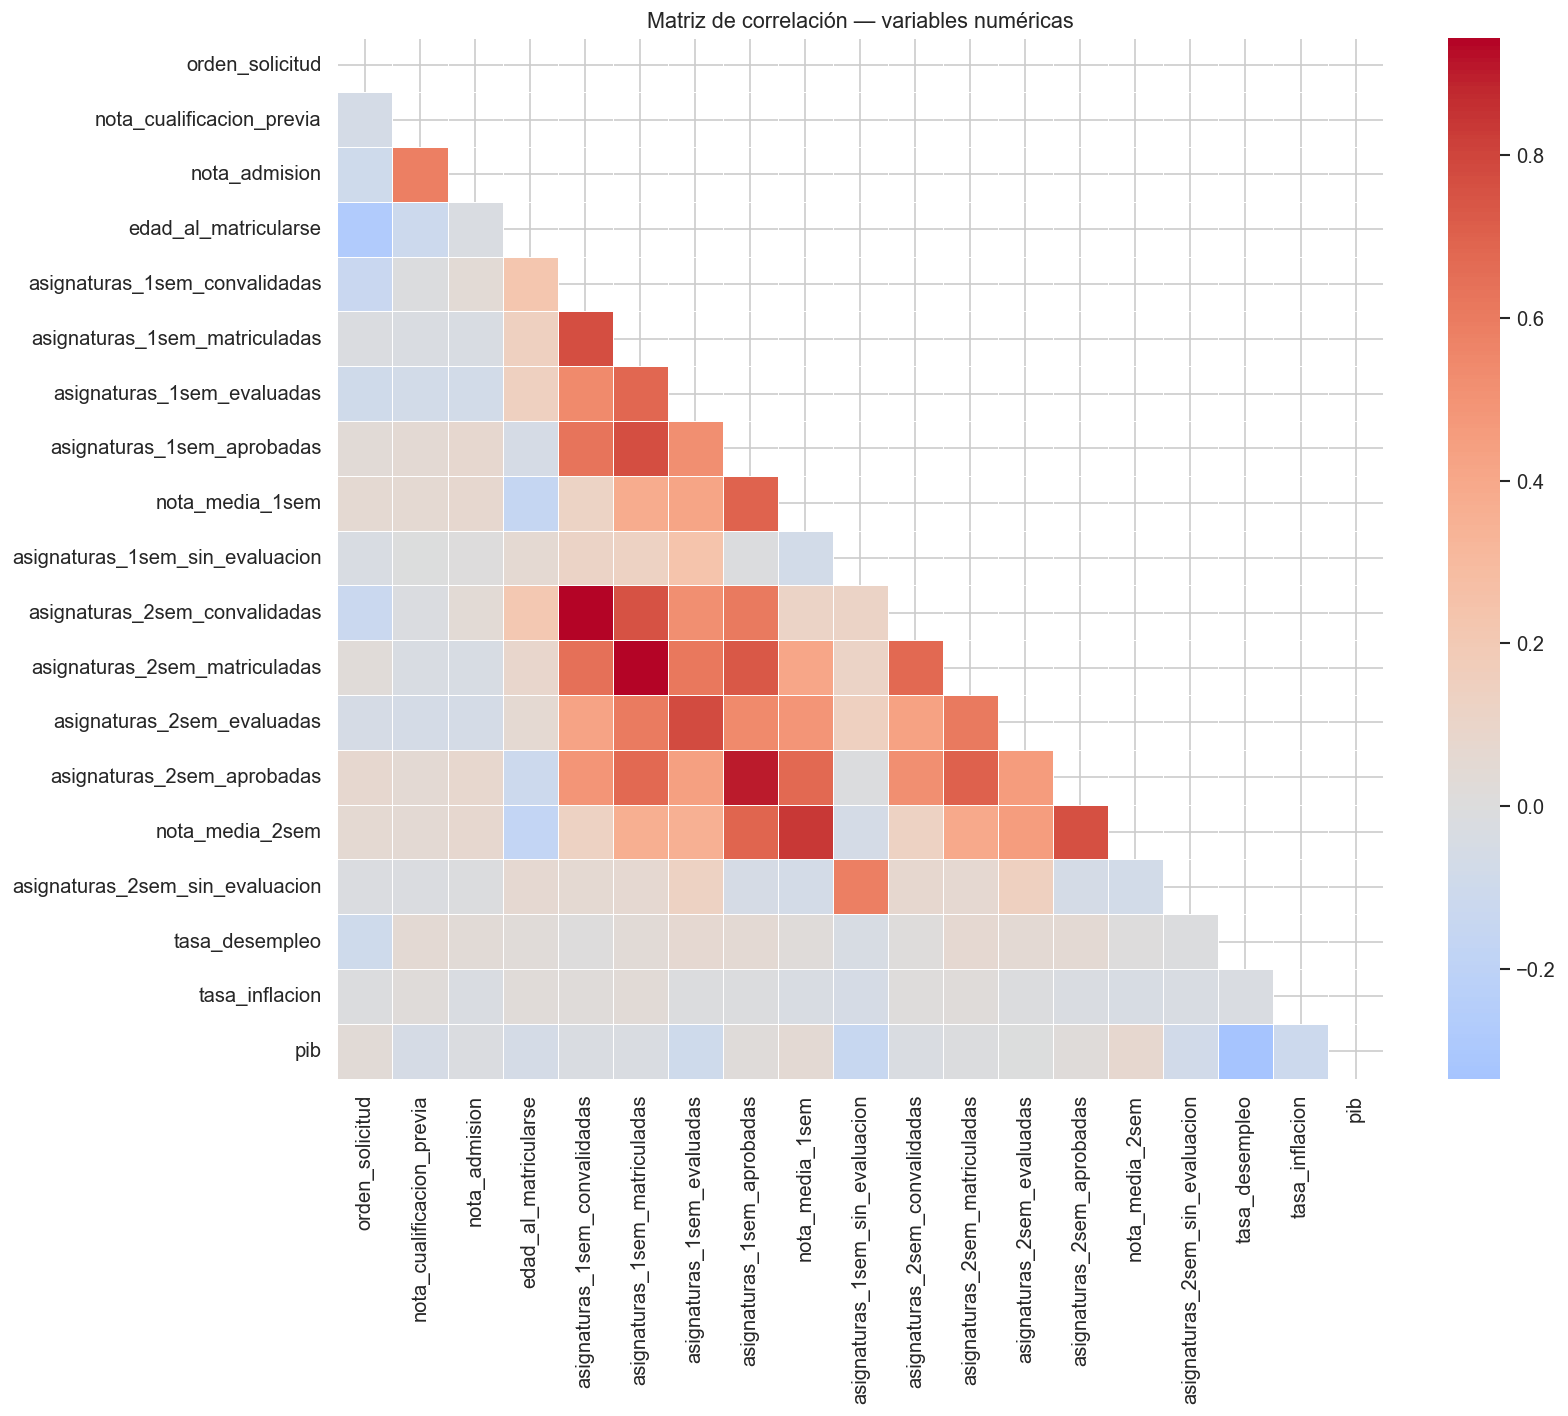

In [10]:
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0,
            annot=False, linewidths=0.3, ax=ax)
ax.set_title("Matriz de correlación — variables numéricas", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/00_correlacion.png", bbox_inches="tight")
plt.show()

## 9. Correlación con nota_media_2sem (target de regresión)

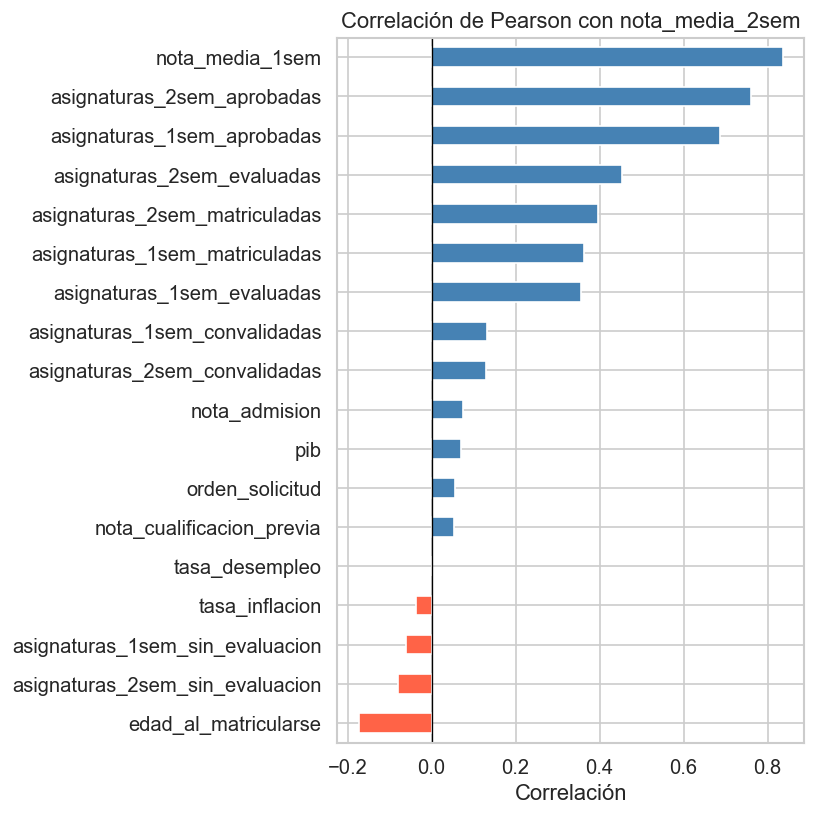

In [11]:
corr_target = (df[num_cols].corr()["nota_media_2sem"]
               .drop("nota_media_2sem")
               .sort_values())

fig, ax = plt.subplots(figsize=(7, 7))
colors = ["tomato" if v < 0 else "steelblue" for v in corr_target]
corr_target.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlación de Pearson con nota_media_2sem")
ax.set_xlabel("Correlación")
plt.tight_layout()
plt.savefig("../outputs/00_correlacion_target_reg.png", bbox_inches="tight")
plt.show()

## 10. Resumen de hallazgos

In [12]:
print("""
RESUMEN EDA
===========
1. Sin valores nulos → no se requiere imputación.
2. Clase 'Matriculado' es la minoría (~18 %) → desbalanceo notable.
3. Predictores más discriminantes:
   - nota_media_1sem, asignaturas_1sem_aprobadas  (rendimiento inicial)
   - nota_admision, nota_cualificacion_previa      (perfil de entrada)
   - matricula_al_dia, deudor                      (situación económica)
4. Para regresión: excluir variables del 2.º semestre (data leakage).
5. Alta correlación intra-semestre → posible multicolinealidad.
""")


RESUMEN EDA
1. Sin valores nulos → no se requiere imputación.
2. Clase 'Matriculado' es la minoría (~18 %) → desbalanceo notable.
3. Predictores más discriminantes:
   - nota_media_1sem, asignaturas_1sem_aprobadas  (rendimiento inicial)
   - nota_admision, nota_cualificacion_previa      (perfil de entrada)
   - matricula_al_dia, deudor                      (situación económica)
4. Para regresión: excluir variables del 2.º semestre (data leakage).
5. Alta correlación intra-semestre → posible multicolinealidad.

